# **Country Intelligence System using Machine Learning**
# Objectives of the Model

1. Clean and preprocess the country dataset by handling missing values and duplicate records.

2. Standardize numerical features to ensure all variables contribute equally during clustering.

3. Identify hidden patterns and similarities among countries using unsupervised machine learning techniques.

4. Determine the optimal number of clusters using the Elbow Method.

5. Segment countries into meaningful groups using K-Means clustering.

6. Evaluate clustering quality using the Silhouette Score.

7. Compare clustering results with DBSCAN to identify dense country groups and outliers.

8. Reduce high-dimensional data into two principal components using PCA.

9. Visualize country clusters through a two-dimensional scatter plot.

10. Generate socio-economic insights regarding mortality rates, income levels, GDP, healthcare expenditure, and development status of countries.


**This project analyzes country-level socio-economic indicators using unsupervised machine learning techniques. K-Means clustering, DBSCAN clustering, PCA, the Elbow Method, and Silhouette Score are used to identify meaningful country segments and generate socio-economic insights.**

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Dataset Loading

The Country-data.csv dataset is loaded into the notebook for analysis. The dataset contains various socio-economic and health indicators for different countries.

In [7]:
df = pd.read_csv('/content/Country-data.csv')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# Data Cleaning

The dataset is cleaned by removing extra spaces from column names, eliminating duplicate records, converting columns into numeric format, and replacing missing values using median imputation.

In [8]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Remove duplicate records
df = df.drop_duplicates()

# Select numerical feature columns (excluding country name)
feature_columns = df.columns[1:]

# Convert features to numeric format
df[feature_columns] = df[feature_columns].apply(
    pd.to_numeric,
    errors='coerce'
)

# Fill missing values with median
for col in feature_columns:
    df[col] = df[col].fillna(df[col].median())

# Display dataset information
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


# Feature Selection and Data Scaling

The country name column is removed because it is a categorical identifier. The remaining numerical features are standardized using StandardScaler to ensure all variables contribute equally to clustering.

In [9]:
# Separate country names from numerical features
country_names = df['country']

# Remove country column
X = df.drop('country', axis=1)

# Display feature matrix shape
print("Features Shape:", X.shape)

# Standardize the features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Features Shape: (167, 9)


# Elbow Method for Optimal Cluster Selection

The Elbow Method is used to determine the optimal number of clusters by calculating inertia values for cluster sizes ranging from 2 to 10.

In [10]:
inertia_values = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia_values.append(kmeans.inertia_)

# Elbow Method Visualization

The inertia values are plotted against the number of clusters. The elbow point indicates the most appropriate cluster count for K-Means clustering.


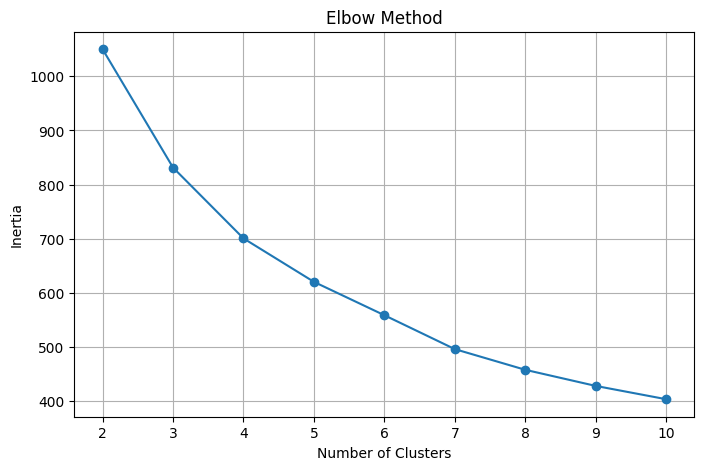

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia_values,
    marker='o'
)

plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.grid(True)

plt.show()

# K-Means Clustering

Based on the Elbow Method, K = 3 is selected as the baseline cluster count. The K-Means model is trained and cluster labels are assigned to each country.

In [12]:
best_k = 3

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


# Cluster Evaluation using Silhouette Score

The Silhouette Score is calculated to evaluate clustering quality. A higher score indicates better cluster separation and stability.

In [13]:
score = silhouette_score(
    X_scaled,
    df['Cluster']
)

print("Silhouette Score:", score)

Silhouette Score: 0.28329575683463126


# DBSCAN Clustering

A secondary clustering model, DBSCAN, is developed to compare clustering results with K-Means and identify density-based groupings.


In [14]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster,DBSCAN_Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1,-1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2,0


# Principal Component Analysis (PCA)

PCA reduces the high-dimensional dataset into two principal components for visualization and interpretation of country segments.

In [15]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

df['PCA1'] = pca_data[:,0]
df['PCA2'] = pca_data[:,1]

# PCA Scatter Plot Visualization

The PCA scatter plot displays country clusters in two dimensions. Different colors represent different K-Means clusters, allowing visual evaluation of cluster separation.

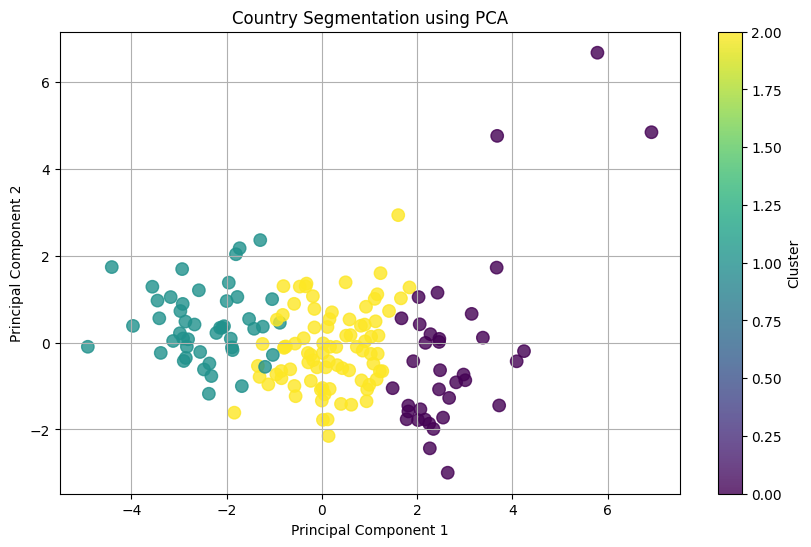

In [16]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    df['PCA1'],
    df['PCA2'],
    c=df['Cluster'],
    cmap='viridis',
    s=80,
    alpha=0.8
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Country Segmentation using PCA')

plt.colorbar(scatter, label='Cluster')

plt.grid(True)

plt.show()

# Cluster Summary Analysis

The average values of each feature are calculated for every cluster to better understand the socio-economic characteristics of different country groups.

In [17]:
# Display average feature values for each cluster

cluster_summary = df.groupby('Cluster').mean(numeric_only=True)

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,DBSCAN_Cluster,PCA1,PCA2
Cluster,,,,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444,-0.250000,2.769773,-0.213014
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979,-0.340426,-2.434620,0.411276
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381,-0.059524,0.175182,-0.138827


# Observations and Insights

### Observation 1
Countries in Cluster 2 exhibit higher child mortality rates, lower life expectancy, and lower GDP per capita, indicating lower socio-economic development.

### Observation 2
Countries in Cluster 0 represent the strongest economic regions with high income levels, high GDP, and better healthcare outcomes.

### Observation 3
Cluster 1 consists of developing countries that show moderate economic growth and improving socio-economic conditions.

### Observation 4
A strong relationship exists between economic prosperity and quality-of-life indicators. Countries with higher income generally have lower mortality rates and higher life expectancy.

### Observation 5
The clustering model successfully identifies distinct country groups, making it useful for socio-economic analysis and policy planning.